# lab1.1


---

## 📋 Table of Contents
1. [Introduction](#1-introduction)
2. [Import Libraries & Load Data](#2-import-libraries--load-data)
3. [Dataset Overview](#3-dataset-overview)
4. [Missing Value Analysis](#4-missing-value-analysis)

---

## 1. Introduction

The **Titanic dataset** is one of the most famous datasets in data science. On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing 1,502 out of 2,224 passengers and crew.

### 🎯 Objective
In this notebook, we perform a thorough **Exploratory Data Analysis (EDA)** to uncover patterns in survival rates across different passenger groups. We answer questions like:
- Did gender affect survival chances?
- Did passenger class matter?
- What role did age play?
- Which features are most important for predicting survival?

This notebook is designed as a **complete beginner's guide** — every step is explained clearly with visualizations and insights.

### 📦 Dataset Columns
| Column | Description |
|---|---|
| PassengerId | Unique ID for each passenger |
| Survived | 0 = No, 1 = Yes |
| Pclass | Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Name | Passenger name |
| Sex | Gender |
| Age | Age in years |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C=Cherbourg, Q=Queenstown, S=Southampton) |

## 2. Import Libraries & Load Data

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [3]:
# Load data
df = pd.read_csv('./Titanic-Dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
df.head()

Dataset shape: (891, 12)
Rows: 891 | Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Dataset Overview

Let's get a high-level understanding of the dataset — data types, basic statistics, and structure.

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Statistical summary
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [6]:
# Categorical columns summary
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


## 4. Missing Value Analysis

Before any analysis, we must understand where data is missing. Missing values can heavily influence our conclusions if not handled properly.

In [7]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing)

          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


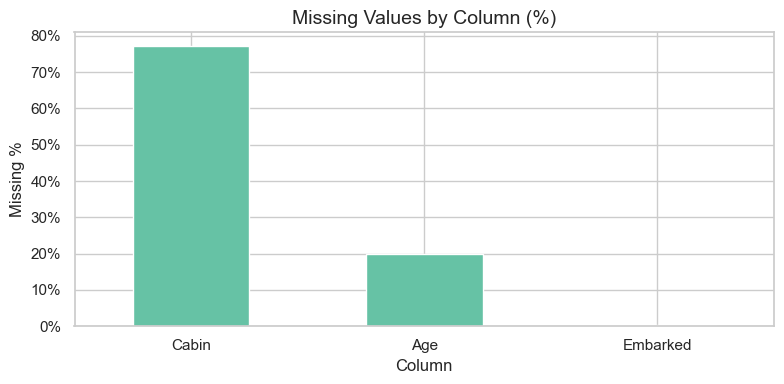

In [8]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing['Missing %'].plot(kind='bar', color=sns.color_palette('Set2')[0], ax=ax)
ax.set_title('Missing Values by Column (%)')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 🔍 Missing Value Observations
- **Cabin** (~77% missing) — Too many missing values to use directly. Can be converted to a binary `HasCabin` feature.
- **Age** (~20% missing) — Significant but manageable. Can be imputed using median age by Pclass and Sex.
- **Embarked** (~0.2% missing) — Only 2 values missing. Can be filled with the mode (most common port).

## 5.Data Preprocessing

In [9]:
#特征处理
df=pd.concat([df,
             pd.get_dummies(df['Sex']).astype(int),
             pd.get_dummies(df['Embarked'],prefix='Embarked').astype(int),
             pd.get_dummies(df['Pclass'],prefix='class').astype(int)],axis=1)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,female,male,Embarked_C,Embarked_Q,Embarked_S,class_1,class_2,class_3
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1,0,0,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0,1,0,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0,0,0,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,0,0,0,1,1,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,0,0,1,0,0,1


In [10]:
#缺失值处理
df['Age']=df['Age'].fillna(df.Age.mean())
df['Fare']=df['Fare'].fillna(df.Fare.mean())


In [11]:
#删除多余数据
df_clean=df.drop(['PassengerId','Name','Ticket','Cabin','Sex','Embarked','Pclass'],axis=1)
df_clean.head()



,Survived,Age,SibSp,Parch,Fare,female,male,Embarked_C,Embarked_Q,Embarked_S,class_1,class_2,class_3
0,0,22.0,1,0,7.2500,0,1,0,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,0,1,0,0,1,0,0
2,1,26.0,0,0,7.9250,1,0,0,0,1,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,0,1,1,0,0
4,0,35.0,0,0,8.0500,0,1,0,0,1,0,0,1


In [12]:
# 数据切分
labels=df_clean['Survived'].to_numpy()

df_clean=df_clean.drop(['Survived'],axis=1)
data=df_clean.to_numpy()

feature_names=list(df_clean.columns)

np.random.seed(10)
train_indices=np.random.choice(len(labels),int(0.7*len(labels)),replace=False)
test_indices=list(set(range(len(labels)))-set(train_indices))

train_features=data[train_indices]
train_labels=labels[train_indices]

test_features=data[test_indices]
test_labels=labels[test_indices]

len(test_labels)


268

## 6.Model Building

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F 

# 设置随机种子
torch.manual_seed(0)

# 定义MLP模型
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.criterion = nn.CrossEntropyLoss()  # 交叉熵损失函数，用于计算模型误差
        # 定义三个线性层，用于处理输入特征
        --------------------------------------------------------------------------
        #TODO

    def forward(self, x):
        ---------------------------------------------------------------------------
        #TODO

    def getloss_accuarcy(self, x, y):
        # 计算模型预测值与实际标签之间的交叉熵损失
        y_pred = self.forward(x)
        loss = self.criterion(y_pred, y)
        acc = accuracy(y_pred, y)
        # 返回计算得到的损失值
        return loss, acc

def accuracy(y_hat, y_true):
    ---------------------------------------------------------------------------
        #TODO
    return acc

In [ ]:

if __name__ == '__main__':
    # 创建 ThreelinearModel 的神经网络模型
    net = MLP()
    # 设置训练轮数为150次，选择Adam优化器，学习率为0.04
    num_epochs = 50
    optimizer = torch.optim.Adam(net.parameters(), lr=0.04)
    
    # 将训练数据转换为PyTorch张量格式
    input_tensor = torch.from_numpy(train_features).type(torch.FloatTensor)
    label_tensor = torch.from_numpy(train_labels)
    
    input_tensor_test = torch.from_numpy(test_features).type(torch.FloatTensor)
    label_tensor_test = torch.from_numpy(test_labels)

    # 用于存储每轮训练的损失值
    losses_train = []
    losses_test = []
    
    # 用于储存每轮训练的准确率
    accuracy_train = []
    accuracy_test = []
    
    # 开始训练循环
    for epoch in range(num_epochs):
        # 计算当前模型在训练数据上的损失值
        loss_train, acc_train = net.getloss_accuarcy(input_tensor, label_tensor)
        loss_test, acc_test = net.getloss_accuarcy(input_tensor_test, label_tensor_test)
        # 记录损失值
        losses_train.append(loss_train.item())
        losses_test.append(loss_test.item())
        # 记录准确率
        accuracy_train.append(acc_train)
        accuracy_test.append(acc_test)
        # 清零梯度，防止梯度累积
        -----------------------------------------------------------------------------
        #TODO
        # 反向传播，计算梯度
        -----------------------------------------------------------------------------
        #TODO
        # 更新模型参数
        -----------------------------------------------------------------------------
        #TODO
        # 每20轮打印一次训练损失
        if epoch % 20 == 0:
            print('Epoch {}/{} => Train_Loss: {:.2f}. Test_Loss:{:.2f}'.format(epoch + 1, num_epochs, loss_train.item(), loss_test.item()))
    
    # 创建'models'文件夹（如果不存在），保存训练好的模型参数
    os.makedirs('models', exist_ok=True)
    torch.save(net.state_dict(), 'models/titanic_model.pt')

    # 使用训练好的模型进行训练集的预测
    out_probs = net(input_tensor).detach().numpy()
    out_classes = np.argmax(out_probs, axis=1)
    # 输出训练集准确率
    print("Training Accuracy: ", sum(out_classes == train_labels) / len(train_labels))
    
    # 使用训练好的模型进行测试集的预测
    test_input_tensor = torch.from_numpy(test_features).type(torch.FloatTensor)
    out_probs = net(test_input_tensor).detach().numpy()
    out_classes = np.argmax(out_probs, axis=1)
    # 输出测试集准确率
    print("Testing Accuracy: ", sum(out_classes == test_labels) / len(test_labels))


Epoch 1/50 => Train_Loss: 0.74. Test_Loss:0.73
Epoch 21/50 => Train_Loss: 0.57. Test_Loss:0.59
Epoch 41/50 => Train_Loss: 0.50. Test_Loss:0.49
Training Accuracy:  0.8138041733547352
Testing Accuracy:  0.8134328358208955


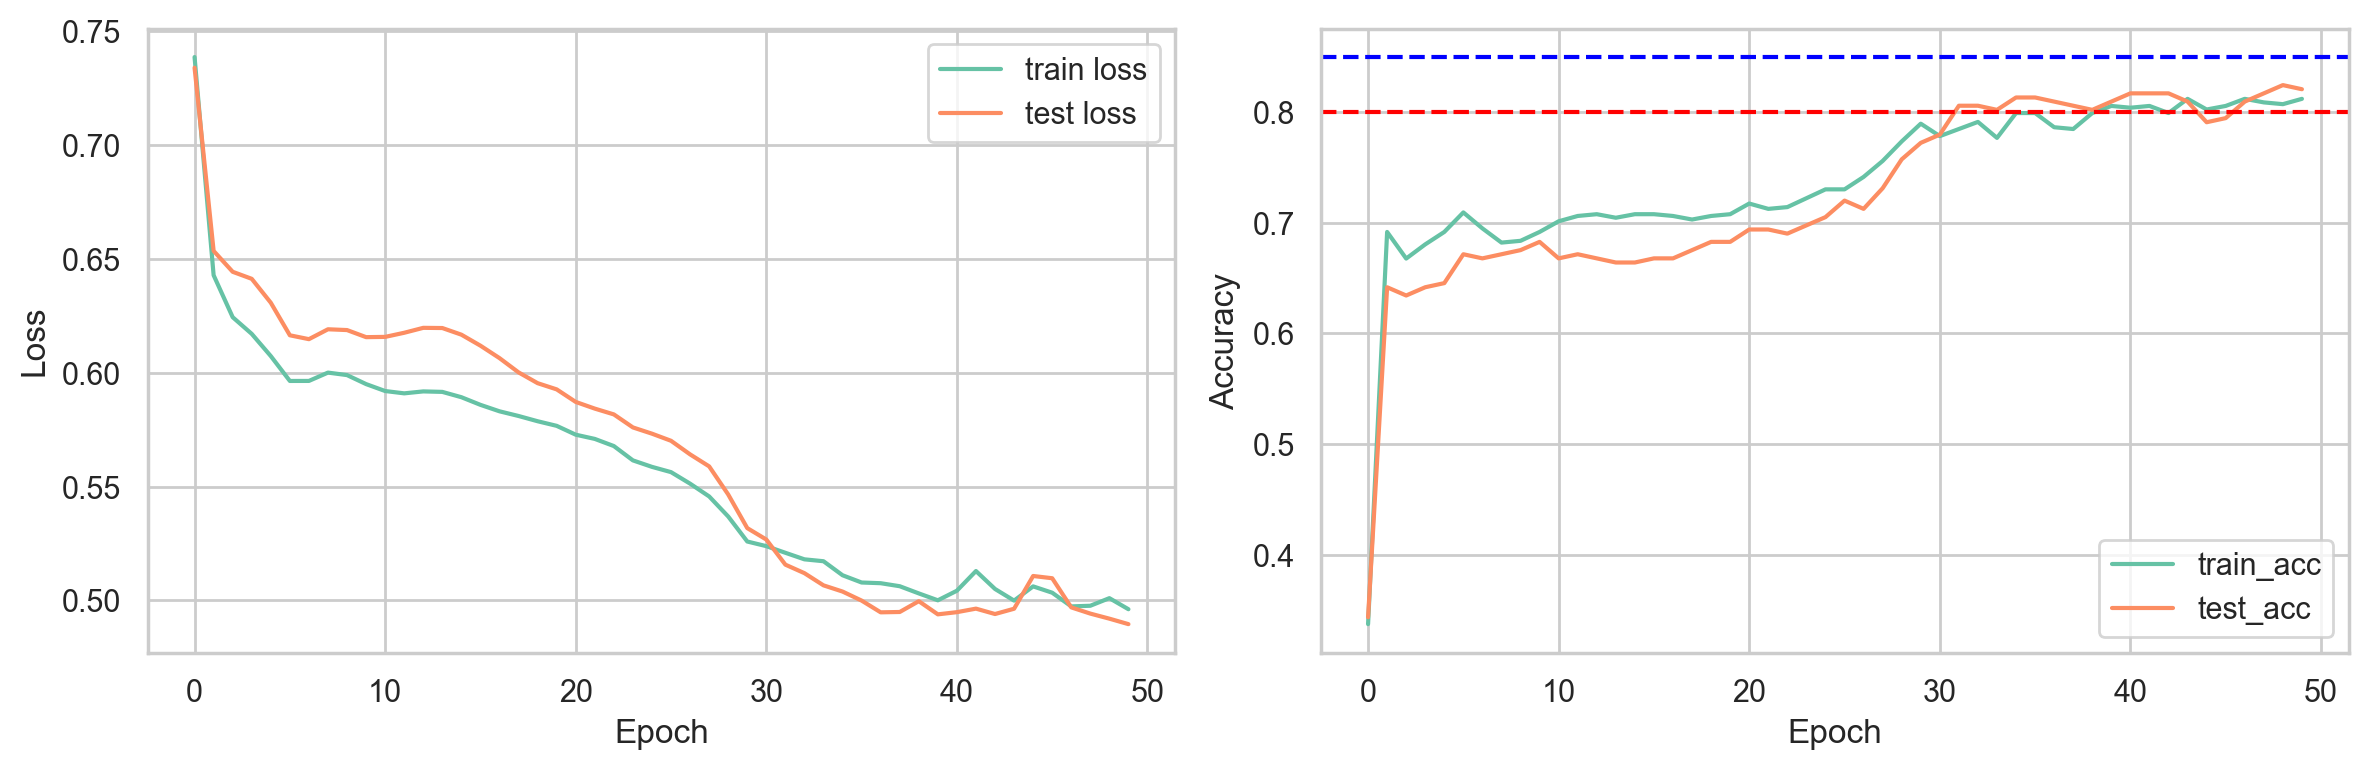

In [28]:
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# 绘制第一个子图
axs[0].plot(losses_train, label="train loss")

axs[0].plot(losses_test, label="test loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

# 绘制第二个子图
axs[1].plot(accuracy_train, label="train_acc")
axs[1].plot(accuracy_test, label="test_acc")
axs[1].axhline(y=0.8, color='r', linestyle='--')  # 添加 y=0.9 的参考线
axs[1].axhline(y=0.85, color='b', linestyle='--')  # 添加 y=0.85 的参考线
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()